In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib_venn import venn2

In [8]:
def calculate_and_plot_venn(
    df: pd.DataFrame, col_a: str, col_b: str, label_a: str , label_b: str , output: str
) -> dict:
    mask_a = df[col_a].astype(bool)
    mask_b = df[col_b].astype(bool)

    # Calculate metrics using bitwise logical operators
    a_not_b = int((mask_a & ~mask_b).sum())
    b_not_a = int((~mask_a & mask_b).sum())
    a_and_b = int((mask_a & mask_b).sum())

    # Print the metrics directly to the terminal
    print(f"--- Venn Metrics for Boolean Columns '{col_a}' vs '{col_b}' ---")
    print(f"True in {label_a} only (Ab):  {a_not_b}")
    print(f"True in both {label_a} & {label_b} (AB):  {a_and_b}")
    print(f"True in {label_b} only (aB):  {b_not_a}")
    print("-" * 55)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(3, 3))

    # subsets=(Ab, aB, AB)
    venn2(subsets=(a_not_b, b_not_a, a_and_b), set_labels=(label_a, label_b), ax=ax)
   
    fig.savefig(output, dpi=300)



TSP:
All:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  4957
True in both POC & WSOC (AB):  2171
True in WSOC only (aB):  2341
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  4620
True in both Weekend & Weekday (AB):  3405
True in Weekday only (aB):  1444
-------------------------------------------------------
With MS2:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  237
True in both POC & WSOC (AB):  505
True in WSOC only (aB):  75
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  84
True in both Weekend & Weekday (AB):  685
True in Weekday only (aB):  48
---------------------------

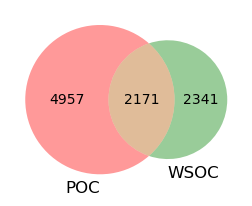

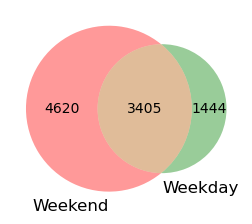

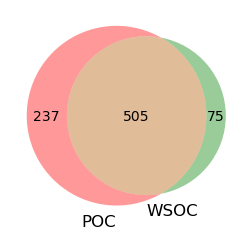

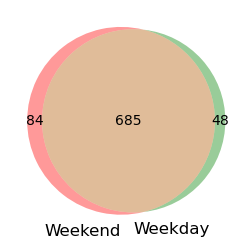

In [36]:
print('TSP:')
print('All:')

da_tsp_df=pd.read_csv('../results/easvolee_tsp_pos/analysis/features/da.csv', low_memory=False)


calculate_and_plot_venn(da_tsp_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_tsp_fraction.png')
calculate_and_plot_venn(da_tsp_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_tsp_daytype.png')

da_tsp_ms2_df=da_tsp_df[da_tsp_df['has_ms2']]

print('With MS2:')

calculate_and_plot_venn(da_tsp_ms2_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_tsp_fraction_blank.png')
calculate_and_plot_venn(da_tsp_ms2_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_tsp_daytype_blank.png')



UFP:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  5005
True in both POC & WSOC (AB):  1806
True in WSOC only (aB):  2595
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  2355
True in both Weekend & Weekday (AB):  4454
True in Weekday only (aB):  2597
-------------------------------------------------------
UFP:
--- Venn Metrics for Boolean Columns 'detected:fraction:POC' vs 'detected:fraction:WSOC' ---
True in POC only (Ab):  224
True in both POC & WSOC (AB):  357
True in WSOC only (aB):  90
-------------------------------------------------------
--- Venn Metrics for Boolean Columns 'detected:day_type:weekend' vs 'detected:day_type:weekday' ---
True in Weekend only (Ab):  32
True in both Weekend & Weekday (AB):  558
True in Weekday only (aB):  81
-------------------------------------

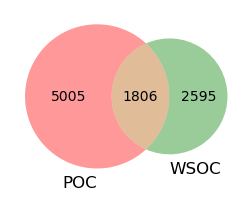

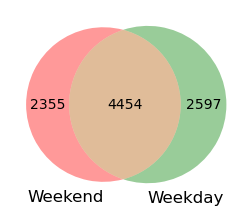

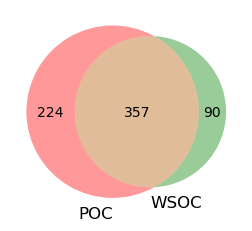

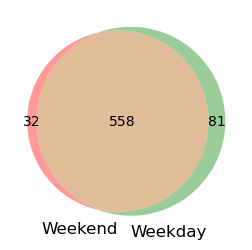

In [37]:
print('UFP:')


da_ufp_df=pd.read_csv('../results/easvolee_ufp_pos/analysis/features/da.csv', low_memory=False)
da_tsp_df=da_ufp_df[da_ufp_df['has_ms2']]

calculate_and_plot_venn(da_ufp_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_ufp_fraction.png')


calculate_and_plot_venn(da_ufp_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_ufp_daytype.png')

print('UFP:')

da_ufp_df=pd.read_csv('../results/easvolee_ufp_pos/analysis/features/da.csv', low_memory=False)
da_ufp_df=da_ufp_df[da_ufp_df['has_ms2']]

calculate_and_plot_venn(da_ufp_df, 'detected:fraction:POC','detected:fraction:WSOC', "POC",'WSOC','../additional_figures/venn_ufp_fraction_blank.png')
calculate_and_plot_venn(da_ufp_df, 'detected:day_type:weekend','detected:day_type:weekday', "Weekend",'Weekday','../additional_figures/venn_ufp_daytype_blank.png')

In [13]:
import seaborn as sns
import numpy as np

def plot_filtered_counts(
    a_df:  pd.DataFrame,
    b_df: pd.DataFrame,
    a_label: str,
    b_label: str,
    target_col: str,
    prob_col: str,
    threshold: float ,
    output: str
):
    filtered_a_df = a_df[a_df[prob_col] > threshold]
    counts_a = filtered_a_df[target_col].value_counts()
    counts_a = counts_a[counts_a > 4]

    filtered_b_df = b_df[b_df[prob_col] > threshold]
    counts_b = filtered_b_df[target_col].value_counts()
    counts_b = counts_b[counts_b > 4]

    width = 0.4
    all_labels = sorted(set(counts_a.index) | set(counts_b.index), key=lambda l: -(counts_a.get(l, 0) + counts_b.get(l, 0)))
    x = np.arange(len(all_labels))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, [counts_a.get(l, 0) for l in all_labels], width=width, label=a_label)
    ax.bar(x + width/2, [counts_b.get(l, 0) for l in all_labels], width=width, label=b_label)
    ax.set_xticks(x)
    ax.set_xticklabels(all_labels, rotation=45, ha="right")
    ax.set_xlabel(target_col, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output,dpi=300)

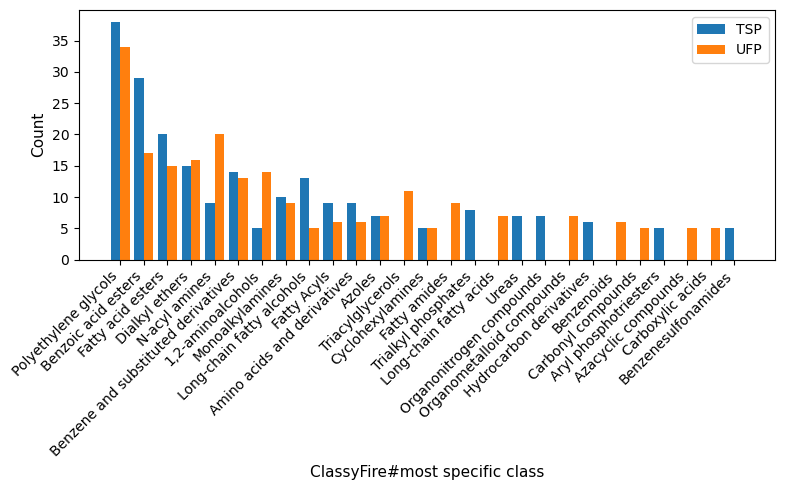

In [14]:
canopus_classes_tsp=pd.read_csv('../results/easvolee_tsp_pos/sirius/summaries/canopus_structure_summary.tsv',sep='\t')
canopus_classes_ufp=pd.read_csv('../results/easvolee_ufp_pos/sirius/summaries/canopus_structure_summary.tsv',sep='\t')
plot_filtered_counts(canopus_classes_tsp, canopus_classes_ufp, 'TSP','UFP', 'ClassyFire#most specific class','ClassyFire#most specific class Probability',0.7, '../additional_figures/canopus.png')